# Pipeline Tag Prediction
## Baseline - TF-IDF & Logistic Regression

**DATASCI 266: Natural Language Processing with Deep Learning**

UC Berkeley, School of Information

---

This notebook implements the baseline model using TF-IDF and Logistic Regression. It runs in this order:

1. Load cleaned dataset
2. Train/test/validation split
3. Format model card text
4. Setup TF-IDF and encode labels
5. Logistic regression model
6. Predictions and metric analysis
7. Error analysis
8. Export dataframes for improvement models

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings, re, ast
from datasets import load_dataset, DatasetDict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import joblib

warnings.filterwarnings('ignore')

# Plot defaults
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Cleaned Dataset

Importing the cleaned dataset from `model_cards_cleaned.parquet`. See data cleaning file for specifics.

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR = '/content/drive/MyDrive/266-pipeline-tag-prediction'
df = pd.read_parquet(f'{DRIVE_DIR}/model_cards_cleaned.parquet')
metadata = json.load(open(f'{DRIVE_DIR}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']

Mounted at /content/drive


In [3]:
# Preview dataset for current columns and data formats
df.head()

,modelId,pipeline_tag,label,text,char_len,word_count
0,00000tt/OmniDream-LoRas,text-to-image,7,# OmniDream FinalDream LoRas\n\n<Gallery />\n\...,305,40
1,00001a/gemma-4-26B-A4B-it-uncensored-heretic-a...,image-text-to-text,2,# 🦆 zecanard/gemma-4-26B-A4B-it-uncensored-her...,1343,139
2,001szp/Qwen3.5-27B-Claude-4.6-Opus-Reasoning-D...,image-text-to-text,2,# 🌟 Qwen3.5-27B-Claude-4.6-Opus-Reasoning-Dist...,7758,919
3,0057Kanyakorn/distilbert-base-uncased-finetune...,text-classification,5,<!-- This model card has been generated automa...,1425,187
4,006aman/IKS-Mistral-7B,text-generation,6,# Uploaded finetuned model\n\n- **Developed b...,442,33


In [4]:
df.count()

,0
modelId,141036
pipeline_tag,141036
label,141036
text,141036
char_len,141036
word_count,141036


In [5]:
df.value_counts("pipeline_tag")

,count
pipeline_tag,
text-generation,67841
text-to-image,21831
image-text-to-text,12309
text-classification,10218
translation,8589
automatic-speech-recognition,5829
token-classification,4033
sentence-similarity,3726
robotics,3355


## 2. Split Data

Split the data into train, validation, and test dataframes using an 80/10/10 split.

In [6]:
# train/test split
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

In [7]:
# val split
test_df, val_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [8]:
# Verify shapes for each df
print("Shape of train:", train_df.shape)
print("Shape of validation:", val_df.shape)
print("Shape of test:", test_df.shape)

Shape of train: (112828, 6)
Shape of validation: (14104, 6)
Shape of test: (14104, 6)


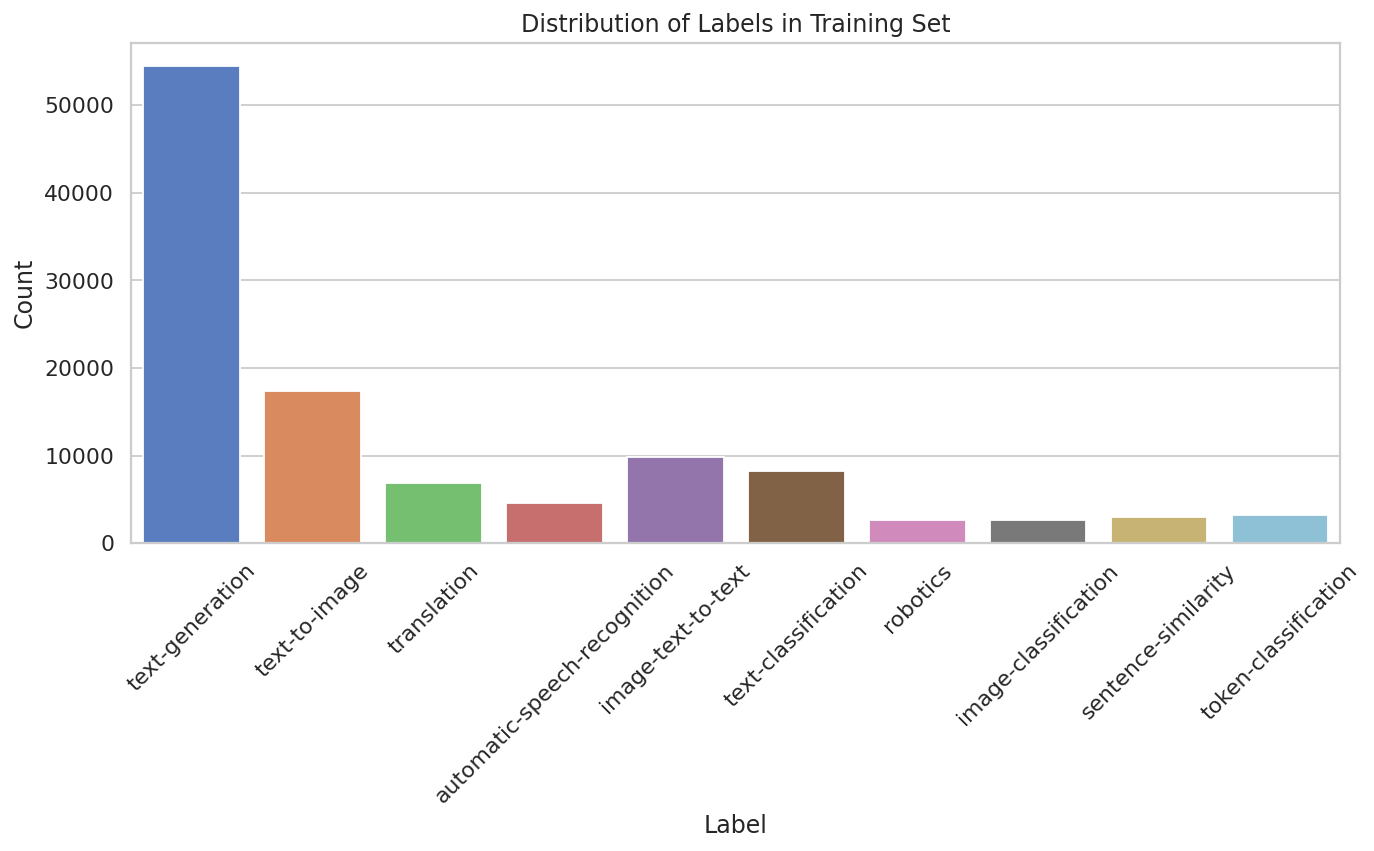

,count
pipeline_tag,
text-generation,54420
text-to-image,17415
image-text-to-text,9810
text-classification,8191
translation,6842
automatic-speech-recognition,4613
token-classification,3247
sentence-similarity,3001
robotics,2667


In [9]:
# Preview label distribution in the training dataset
sns.countplot(x='pipeline_tag', data=train_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Training Set")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

train_df["pipeline_tag"].value_counts()

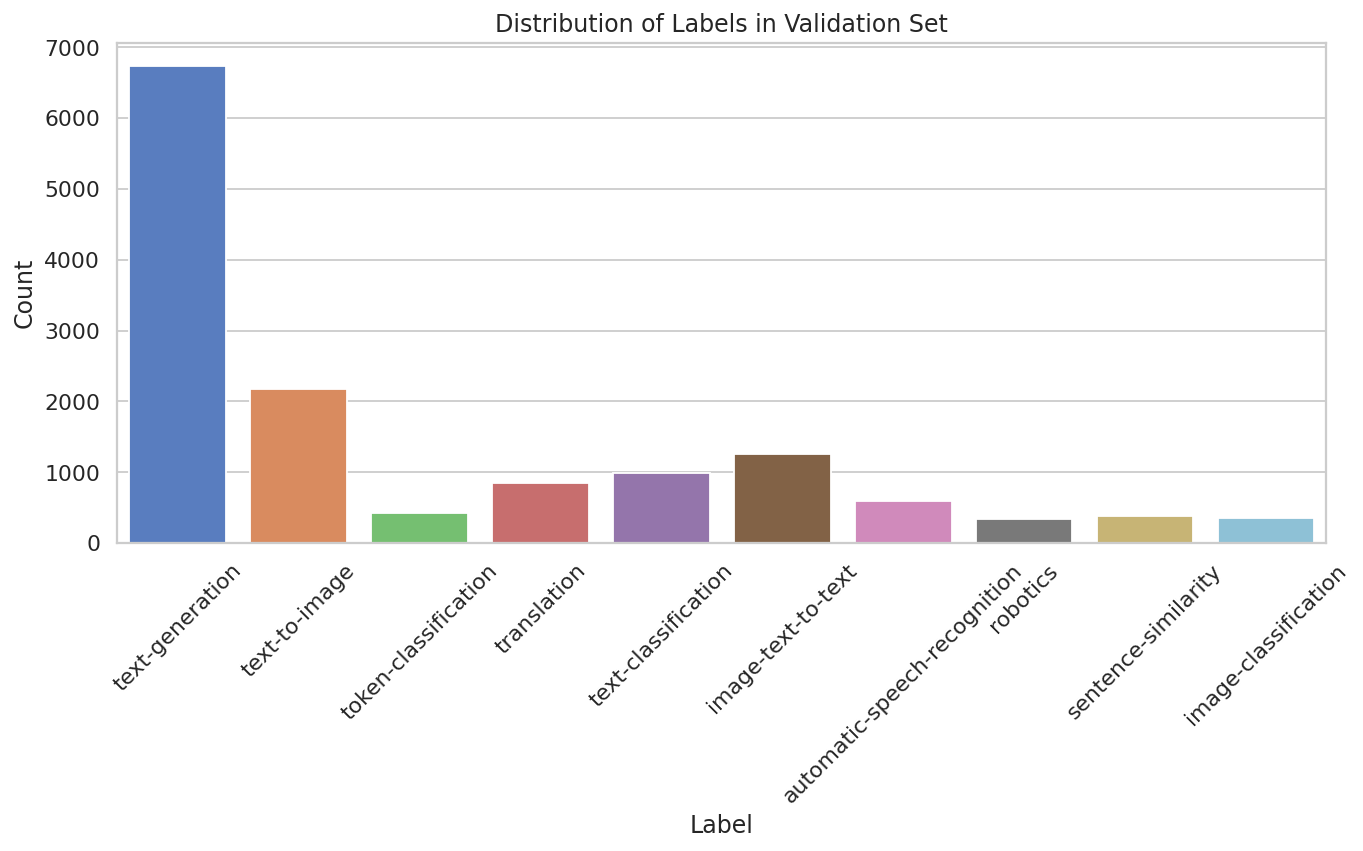

,count
pipeline_tag,
text-generation,6732
text-to-image,2177
image-text-to-text,1259
text-classification,994
translation,844
automatic-speech-recognition,599
token-classification,424
sentence-similarity,382
image-classification,352


In [10]:
# Preview label distribution in the validation dataset
sns.countplot(x='pipeline_tag', data=val_df, hue='pipeline_tag')
plt.title("Distribution of Labels in Validation Set")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

val_df["pipeline_tag"].value_counts()

## 3. Format Inputs

Clean the model card text by changing all letters to lowercase, removing punctuation, removing numbers, and collapsing whitespace, prior to fitting the data.

In [11]:
# Define cleaning function
def clean_text(text: str) -> str:
    """Lowercase, remove punctuation/numbers, collapse whitespace."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
# Apply clean_text to train set
train_df['text_clean']  = train_df['text'].apply(clean_text)
# Apply clean_text to test set
test_df['text_clean']  = test_df['text'].apply(clean_text)
# Apply clean_text to validation set
val_df['text_clean']  = val_df['text'].apply(clean_text)

Print a cleaned example:

In [12]:
# raw unformatted:
print(f'\ntrain: raw answer  : "{train_df["text"].iloc[0]}"')


train: raw answer  : "# Mellum2 Instruct — GGUF (BF16)

This repository contains a **GGUF BF16** quantization of
[`JetBrains/Mellum2-12B-A2.5B-Instruct`](https://huggingface.co/JetBrains/Mellum2-12B-A2.5B-Instruct), ready to run with
[`llama.cpp`](https://github.com/ggml-org/llama.cpp), Ollama, LM Studio, and
other GGUF-compatible runtimes.

**This quantization (BF16):** 16-bit, **no quantization**. The reference these quants are measured against; largest file.

| File | Size |
|---|---|
| `Mellum2-12B-A2.5B-Instruct-BF16.gguf` | 24.3 GB |

Mellum 2 Instruct is a Mixture-of-Experts assistant model (64 experts, 8
activated per token, 131,072-token context) that answers directly, without an
externalized chain of thought. For the full model description, evaluation
results, and architecture details, see the original model card:
**[JetBrains/Mellum2-12B-A2.5B-Instruct](https://huggingface.co/JetBrains/Mellum2-12B-A2.5B-Instruct)**.

## Available quantizations

| Quantization | Description 

In [13]:
# cleaned
print(f'train: clean answer : "{train_df["text_clean"].iloc[0]}"')

train: clean answer : "mellum instruct gguf bf this repository contains a gguf bf quantization of jetbrains mellum b a b instruct https huggingface co jetbrains mellum b a b instruct ready to run with llama cpp https github com ggml org llama cpp ollama lm studio and other gguf compatible runtimes this quantization bf bit no quantization the reference these quants are measured against largest file file size mellum b a b instruct bf gguf gb mellum instruct is a mixture of experts assistant model experts activated per token token context that answers directly without an externalized chain of thought for the full model description evaluation results and architecture details see the original model card jetbrains mellum b a b instruct https huggingface co jetbrains mellum b a b instruct available quantizations quantization description size kld vs bf top token match bf this repo bit no quantization reference gb q https huggingface co jetbrains mellum b a b instruct gguf q bit effectively los

## 4. TF-IDF & Encoding

Setup the TF-IDF vectorizer. We set the max_features to 20,000 as a starting point. Encode the `pipeline_tag` labels. Fit data with training and validation sets.

In [14]:
# Set TF-IDF
# using default norm; l2 for cosine similarity
tf_idf_vec = TfidfVectorizer(max_features=20000, # top 20k features
                             ngram_range=(1,2), # allows bigrams and unigrams
                             sublinear_tf=True, # allow sublinear scaling to reduce skewing to most frequent words (applies a log to term frequency)
                             min_df=5, # dropping any words that show up <5 times
                             )

In [15]:
label_encoder = LabelEncoder()

# Fit w/ training and val
X_train = tf_idf_vec.fit_transform(train_df["text_clean"])
X_val = tf_idf_vec.transform(val_df["text_clean"])

# Fit w/ test
X_test = tf_idf_vec.transform(test_df["text_clean"])

# Encode text labels to int categories
Y_train = label_encoder.fit_transform(train_df["pipeline_tag"])
Y_val = label_encoder.transform(val_df["pipeline_tag"])
Y_test = label_encoder.transform(test_df["pipeline_tag"])

# Print shapes for review
print("Shape of formatted X_train:", X_train.shape)
print("Shape of formatted X_val:", X_val.shape)
print("Shape of formatted X_test:", X_test.shape)
print("Shape of formatted Y_train:", Y_train.shape)
print("Shape of formatted Y_val:", Y_val.shape)
print("Shape of formatted Y_test:", Y_test.shape)

Shape of formatted X_train: (112828, 20000)
Shape of formatted X_val: (14104, 20000)
Shape of formatted X_test: (14104, 20000)
Shape of formatted Y_train: (112828,)
Shape of formatted Y_val: (14104,)
Shape of formatted Y_test: (14104,)


## 5. Logistic Regression Baseline (with Data-Scaling Ablation)

Beyond training on the full dataset, we run a data-scaling ablation to understand how the baseline's performance varies with training set size. The model is retrained from scratch on 25%, 50%, 75%, and 100% of the training data and evaluated on the same test set each time. For every run we record accuracy, macro F1, and weighted F1 so we can compare data efficiency against the RoBERTa and ModernBERT improvement models.


In [16]:
# Baseline w/ Logistic Regression

train_fractions = [0.25, 0.50, 0.75, 1.00]
ablation_results = []

n_train = X_train.shape[0]
shuffled_idx = np.random.RandomState(42).permutation(n_train)

# loop for data scaling ablation
for i in train_fractions:
    print(f"\n=== Training Logistic Regression on {int(i * 100)}% of training data ===")

    n_samples = int(n_train * i)
    idx = shuffled_idx[:n_samples]
    X_train_subset = X_train[idx]
    Y_train_subset = Y_train[idx]

    # Clean model per run
    lr_model = LogisticRegression(max_iter=1000,
                                  class_weight="balanced",
                                  random_state=42,
                                  n_jobs=-1
                                  )

    lr_model.fit(X_train_subset, Y_train_subset)

    test_predictions = lr_model.predict(X_test)

    ablation_results.append({
        "model": "Logistic Regression (TF-IDF)",
        "train_fraction": i,
        "train_samples": n_samples,
        "accuracy": accuracy_score(Y_test, test_predictions),
        "macro_f1": f1_score(Y_test, test_predictions, average="macro"),
        "weighted_f1": f1_score(Y_test, test_predictions, average="weighted"),
    })

    # storing F1 per class per fraction of train set to explore areas for improvement
    per_class_f1 = f1_score(Y_test, test_predictions, average=None, labels=range(len(label_encoder.classes_)))
    ablation_results[-1]["per_class_f1"] = dict(zip(label_encoder.classes_, per_class_f1))


=== Training Logistic Regression on 25% of training data ===

=== Training Logistic Regression on 50% of training data ===

=== Training Logistic Regression on 75% of training data ===

=== Training Logistic Regression on 100% of training data ===


In [17]:
# Data-scaling ablation results (accuracy, macro F1, weighted F1 per training fraction, per class F1)

ablation_df = pd.DataFrame(ablation_results)
ablation_df

,model,train_fraction,train_samples,accuracy,macro_f1,weighted_f1,per_class_f1
0,Logistic Regression (TF-IDF),0.25,28207,0.931367,0.933407,0.933341,{'automatic-speech-recognition': 0.97165991902...
1,Logistic Regression (TF-IDF),0.50,56414,0.939592,0.940513,0.941172,{'automatic-speech-recognition': 0.97406807131...
2,Logistic Regression (TF-IDF),0.75,84621,0.941151,0.944190,0.942703,{'automatic-speech-recognition': 0.97568881685...
3,Logistic Regression (TF-IDF),1.00,112828,0.944697,0.947167,0.946012,{'automatic-speech-recognition': 0.97896440129...


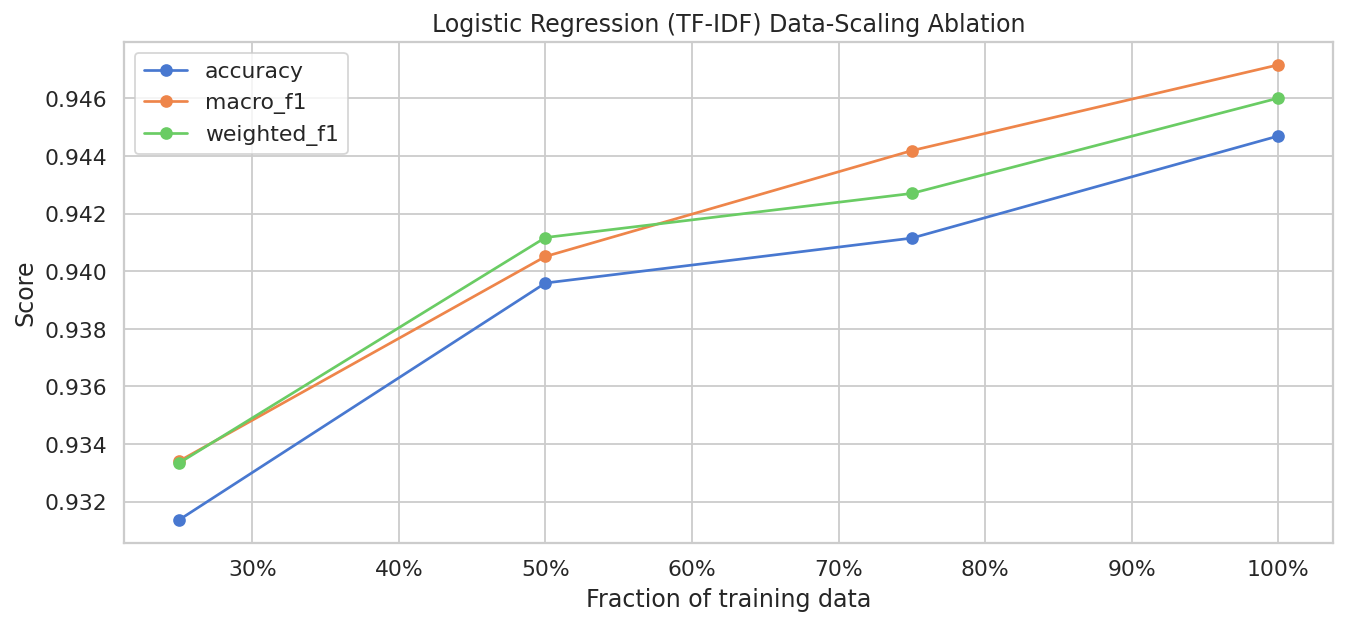

In [18]:
# Plot learning curves: metric vs. training data fraction

fig, ax = plt.subplots()
for metric_name in ["accuracy", "macro_f1", "weighted_f1"]:
    ax.plot(ablation_df["train_fraction"], ablation_df[metric_name], marker="o", label=metric_name)

ax.set_xlabel("Fraction of training data")
ax.set_ylabel("Score")
ax.set_title("Logistic Regression (TF-IDF) Data-Scaling Ablation")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend()
plt.show()

## 6. Predictions and Metrics

Use the logistic regression model to generate predictions for the validation and finally the test datasets. Generate accuracy and macro-F1 scores to evaluate the model on each dataset.

In [19]:
# Save predictions
val_predictions = lr_model.predict(X_val)
test_predictions = lr_model.predict(X_test)

### Save Baseline Model Artifacts

Save the fitted TF-IDF vectorizer, label encoder, and the final logistic regression model (trained on 100% of the training data) to Google Drive. These are needed to run this baseline on new, unlabeled model cards without refitting, and to keep evaluation consistent with what's reported below.

In [20]:
# Save fitted TF-IDF vectorizer, label encoder, and final logistic regression model
# lr_model here is the version trained on 100% of the data from the ablation loop above
joblib.dump(tf_idf_vec, f'{DRIVE_DIR}/tfidf_vectorizer.joblib')
joblib.dump(label_encoder, f'{DRIVE_DIR}/label_encoder.joblib')
joblib.dump(lr_model, f'{DRIVE_DIR}/lr_baseline_model.joblib')

print('Saved TF-IDF vectorizer, label encoder, and logistic regression model to Drive ✓')

Saved TF-IDF vectorizer, label encoder, and logistic regression model to Drive ✓


In [21]:
# Print relevant metrics
print("Validation Accuracy:", accuracy_score(Y_val, val_predictions))
print("Validation Macro-F1:", f1_score(Y_val, val_predictions, average="macro"))

print("Test Accuracy:", accuracy_score(Y_test, test_predictions))
print("Test Macro-F1:", f1_score(Y_test, test_predictions, average="macro"))

Validation Accuracy: 0.9468235961429382
Validation Macro-F1: 0.9500192145851521
Test Accuracy: 0.9446965399886557
Test Macro-F1: 0.9471670185495344


In [22]:
# Print classification report to analyze metrics per `pipeline_tag` label
print(classification_report(Y_test, test_predictions, target_names=label_encoder.classes_))

                              precision    recall  f1-score   support

automatic-speech-recognition       0.98      0.98      0.98       617
        image-classification       0.95      0.97      0.96       331
          image-text-to-text       0.74      0.91      0.82      1240
                    robotics       0.94      0.99      0.96       347
         sentence-similarity       0.98      0.98      0.98       343
         text-classification       0.90      0.95      0.92      1033
             text-generation       0.97      0.92      0.95      6689
               text-to-image       0.99      0.99      0.99      2239
        token-classification       0.93      0.94      0.94       362
                 translation       0.97      0.96      0.97       903

                    accuracy                           0.94     14104
                   macro avg       0.94      0.96      0.95     14104
                weighted avg       0.95      0.94      0.95     14104



## 7. Error Analysis



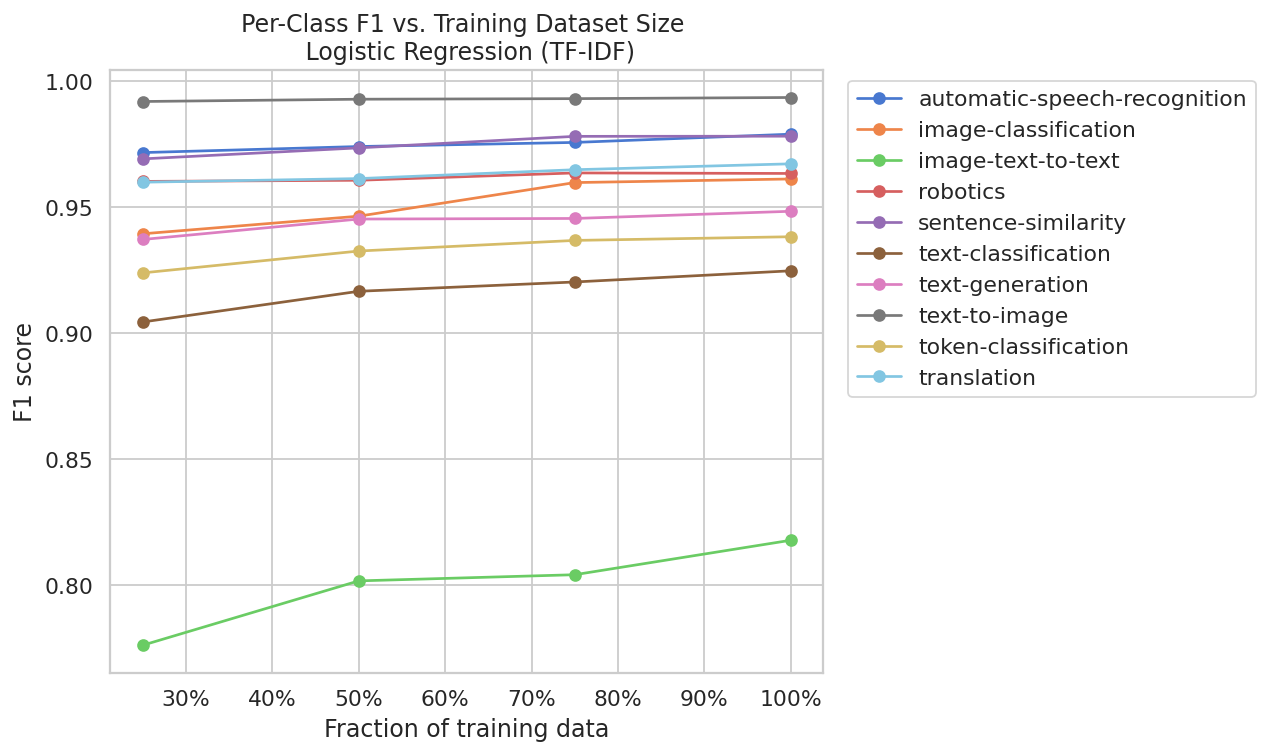

In [23]:
# Per class F1 - does it improve with more data?

per_class_df = pd.DataFrame([r["per_class_f1"] for r in ablation_results])
per_class_df["train_fraction"] = ablation_df["train_fraction"]

fig, ax = plt.subplots(figsize=(10, 6))
for class_name in label_encoder.classes_:
    ax.plot(per_class_df["train_fraction"], per_class_df[class_name], marker="o", label=class_name)

ax.set_xlabel("Fraction of training data")
ax.set_ylabel("F1 score")
ax.set_title("Per-Class F1 vs. Training Dataset Size \n Logistic Regression (TF-IDF)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

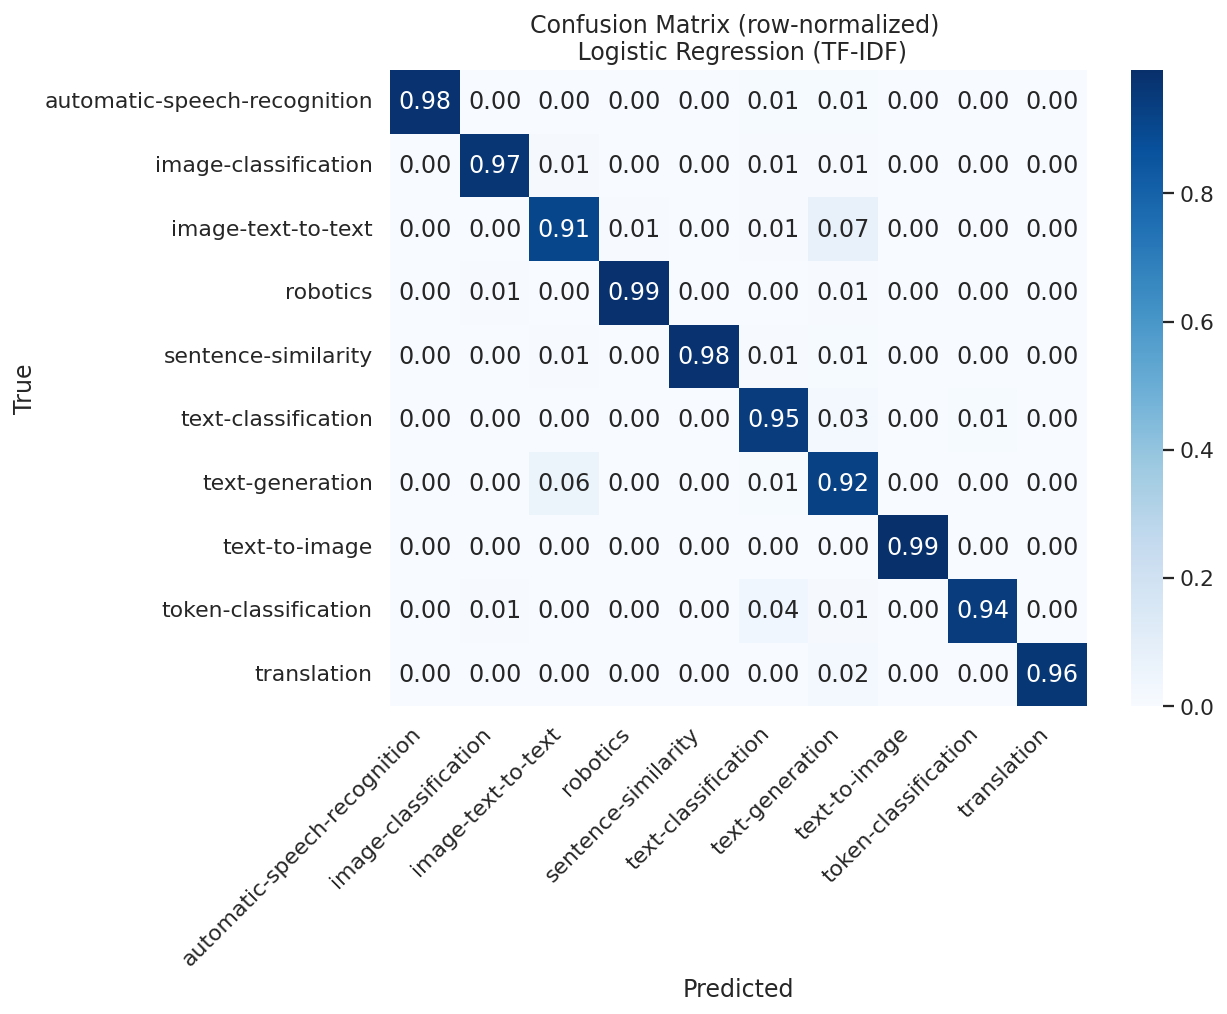

In [24]:
# Confusion Matrix - recall

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, test_predictions, normalize="true")
labels = label_encoder.classes_

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (row-normalized) \n Logistic Regression (TF-IDF)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
# top 10 mislabeled/confused and counts for each confusion pair
cm_counts = confusion_matrix(Y_test, test_predictions)
np.fill_diagonal(cm_counts, 0)

confusion_pairs = []
for i in range(cm_counts.shape[0]):
    for j in range(cm_counts.shape[1]):
        if cm_counts[i, j] > 0:
            confusion_pairs.append({
                "true_label": labels[i],
                "predicted_label": labels[j],
                "count": cm_counts[i, j]
            })

confusion_df = pd.DataFrame(confusion_pairs).sort_values("count", ascending=False)
confusion_df.head(10)

,true_label,predicted_label,count
29,text-generation,image-text-to-text,369
11,image-text-to-text,text-generation,92
32,text-generation,text-classification,70
24,text-classification,text-generation,28
35,text-generation,translation,25
50,translation,text-generation,21
42,token-classification,text-classification,13
34,text-generation,token-classification,13
26,text-classification,token-classification,10
27,text-generation,automatic-speech-recognition,9


In [26]:
# Check actual documents that were misclassified based on confusion matrix

test_df_reset = test_df.reset_index(drop=True)
test_df_reset["true_label"] = label_encoder.inverse_transform(Y_test)
test_df_reset["predicted_label"] = label_encoder.inverse_transform(test_predictions)
test_df_reset["correct"] = test_df_reset["true_label"] == test_df_reset["predicted_label"]

# Worst confusion pair from confusion_df
top_pair = confusion_df.iloc[0]
mask = (test_df_reset["true_label"] == top_pair["true_label"]) & \
       (test_df_reset["predicted_label"] == top_pair["predicted_label"])

misclassified_sample = test_df_reset.loc[mask, ["text", "true_label", "predicted_label"]].sample(
    min(5, mask.sum()), random_state=42
)

for _, row in misclassified_sample.iterrows():
    print(f"TRUE: {row['true_label']} | PRED: {row['predicted_label']}")
    print(row["text"][:500])
    print("-" * 80)

TRUE: text-generation | PRED: image-text-to-text
# Gemma4-39B-A6B Preview

`gemma4-39b-a6b-preview` is a Gemma4 MoE expansion of
`unsloth/Gemma-4-26B-A4B-it`, built with an internal pre-training/post-training
pipeline targeting software engineering, repository reasoning, agentic
workflows, and general instruction following.

This preview build was produced on a 2-GPU local training setup. A larger 52B
build is planned to follow soon as the more stable release line.

## Model Details

- Base model: `unsloth/Gemma-4-26B-A4B-it`
- Architecture: G
--------------------------------------------------------------------------------
TRUE: text-generation | PRED: image-text-to-text
<!-- This model card has been generated automatically according to the information the Trainer had access to. You
should probably proofread and complete it, then remove this comment. -->

# Qwen3-8B-music-coa-sft

This model is a fine-tuned version of [/mnt/tidal-alsh01/usr/zhongmeizhi/meiwangyi/models/Qwen3-8B-onto-fi

In [27]:
N_PAIRS = 5
EXAMPLES_PER_PAIR = 3

for _, pair in confusion_df.head(N_PAIRS).iterrows():
    true_label = pair["true_label"]
    pred_label = pair["predicted_label"]

    mask = (test_df_reset["true_label"] == true_label) & \
           (test_df_reset["predicted_label"] == pred_label)

    sample = test_df_reset.loc[mask, ["text", "true_label", "predicted_label"]].sample(
        min(EXAMPLES_PER_PAIR, mask.sum()), random_state=42
    )

    print(f"\n{'='*90}")
    print(f"TRUE: {true_label}  ->  PREDICTED: {pred_label}   ({pair['count']} occurrences)")
    print('='*90)
    for _, row in sample.iterrows():
        print(f"\n---\n{row['text'][:600]}")


TRUE: text-generation  ->  PREDICTED: image-text-to-text   (369 occurrences)

---
# Gemma4-39B-A6B Preview

`gemma4-39b-a6b-preview` is a Gemma4 MoE expansion of
`unsloth/Gemma-4-26B-A4B-it`, built with an internal pre-training/post-training
pipeline targeting software engineering, repository reasoning, agentic
workflows, and general instruction following.

This preview build was produced on a 2-GPU local training setup. A larger 52B
build is planned to follow soon as the more stable release line.

## Model Details

- Base model: `unsloth/Gemma-4-26B-A4B-it`
- Architecture: Gemma4 MoE
- Total logical parameters: approximately `38.7B`
- Active parameters: approximately `5.9B

---
<!-- This model card has been generated automatically according to the information the Trainer had access to. You
should probably proofread and complete it, then remove this comment. -->

# Qwen3-8B-music-coa-sft

This model is a fine-tuned version of [/mnt/tidal-alsh01/usr/zhongmeizhi/meiwangyi/models/Qwen3-8

In [28]:
# checking vocab overlaps in confused pairs
feature_names = np.array(tf_idf_vec.get_feature_names_out())
TOP_K = 30

for _, pair in confusion_df.head(N_PAIRS).iterrows():
    true_idx = list(label_encoder.classes_).index(pair["true_label"])
    pred_idx = list(label_encoder.classes_).index(pair["predicted_label"])

    true_top = set(feature_names[np.argsort(lr_model.coef_[true_idx])[-TOP_K:]])
    pred_top = set(feature_names[np.argsort(lr_model.coef_[pred_idx])[-TOP_K:]])

    overlap = true_top & pred_top
    print(f"\n{pair['true_label']} vs {pair['predicted_label']}")
    print(f"  Shared top-{TOP_K} features: {len(overlap)}  -> {sorted(overlap)}")


text-generation vs image-text-to-text
  Shared top-30 features: 2  -> ['qwen', 'sft']

image-text-to-text vs text-generation
  Shared top-30 features: 2  -> ['qwen', 'sft']

text-generation vs text-classification
  Shared top-30 features: 0  -> []

text-classification vs text-generation
  Shared top-30 features: 0  -> []

text-generation vs translation
  Shared top-30 features: 0  -> []


In [29]:
def explain_prediction(row_idx, top_k=10):
    x = X_test[row_idx]
    true_label = test_df_reset.loc[row_idx, "true_label"]
    pred_label = test_df_reset.loc[row_idx, "predicted_label"]
    pred_idx = list(label_encoder.classes_).index(pred_label)

    # contribution = tfidf weight * coefficient for the predicted class
    contributions = x.multiply(lr_model.coef_[pred_idx]).toarray().flatten()
    top_idx = np.argsort(contributions)[-top_k:][::-1]

    print(f"TRUE: {true_label}  PRED: {pred_label}")
    print(f"Text: {test_df_reset.loc[row_idx, 'text'][:300]}")
    print("Top words pushing toward the (wrong) prediction:")
    for i in top_idx:
        if contributions[i] > 0:
            print(f"  {feature_names[i]:<25} contribution={contributions[i]:.4f}")
    print()

# Worst pairs
top_pair = confusion_df.iloc[0]
mask = (test_df_reset["true_label"] == top_pair["true_label"]) & \
       (test_df_reset["predicted_label"] == top_pair["predicted_label"])
sample_idx = test_df_reset.loc[mask].sample(min(3, mask.sum()), random_state=42).index

for idx in sample_idx:
    explain_prediction(idx)

TRUE: text-generation  PRED: image-text-to-text
Text: # Gemma4-39B-A6B Preview

`gemma4-39b-a6b-preview` is a Gemma4 MoE expansion of
`unsloth/Gemma-4-26B-A4B-it`, built with an internal pre-training/post-training
pipeline targeting software engineering, repository reasoning, agentic
workflows, and general instruction following.

This preview build was
Top words pushing toward the (wrong) prediction:
  gemma                     contribution=1.1754
  reasoning                 contribution=0.3069
  vllm                      contribution=0.2893
  gemma it                  contribution=0.2695
  thinking                  contribution=0.2039
  unsloth                   contribution=0.1806
  chat template             contribution=0.1746
  moe                       contribution=0.1716
  chat                      contribution=0.1554
  unsloth gemma             contribution=0.1512

TRUE: text-generation  PRED: image-text-to-text
Text: <!-- This model card has been generated automatically accordi

In [30]:
vision_terms = ["image", "vision", "visual", "multimodal", "vlm", "vqa", "ocr"]
family_terms = ["gemma", "qwen", "llama", "mistral", "phi"]

mask = (test_df_reset["predicted_label"] == "image-text-to-text") & \
       (test_df_reset["true_label"] != "image-text-to-text")

subset = test_df_reset.loc[mask, "text_clean"]  # <-- clean, not raw

has_family = subset.apply(lambda t: any(f in t for f in family_terms))
has_vision = subset.apply(lambda t: any(v in t for v in vision_terms))

print(f"Misclassified as image-text-to-text: {mask.sum()}")
print(f"  mentions a model-family name: {has_family.sum()}")
print(f"  mentions family name but NO vision term: {(has_family & ~has_vision).sum()}")

Misclassified as image-text-to-text: 389
  mentions a model-family name: 365
  mentions family name but NO vision term: 134


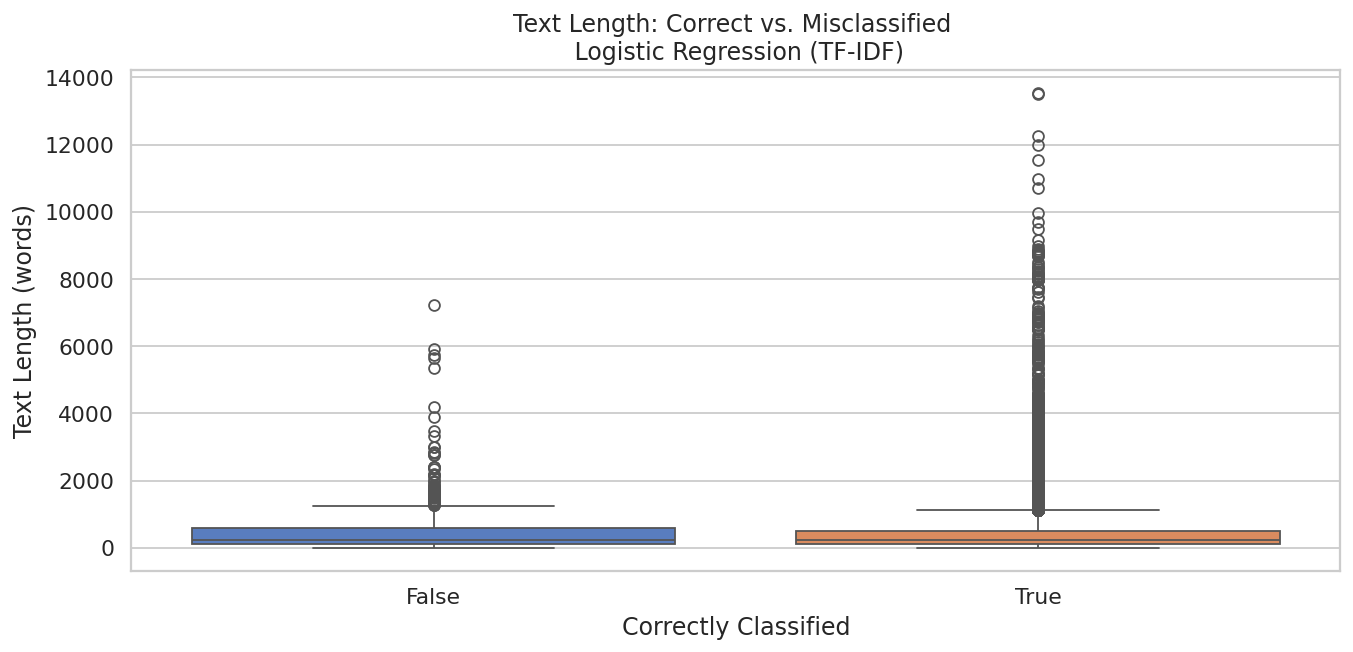

           count        mean         std  min     25%    50%     75%      max
correct                                                                      
False      780.0  488.388462  712.855398  4.0  130.75  233.0  588.50   7221.0
True     13324.0  488.483338  868.136848  1.0  111.00  233.0  514.25  13541.0


In [31]:
# Text length analysis on mislabeled docs

test_df_reset["text_length"] = test_df_reset["text"].str.split().str.len()

fig, ax = plt.subplots()
sns.boxplot(data=test_df_reset, x="correct", y="text_length", hue="correct", ax=ax, legend=False)
ax.set_xlabel("Correctly Classified")
ax.set_ylabel("Text Length (words)")
ax.set_title("Text Length: Correct vs. Misclassified \n Logistic Regression (TF-IDF)")
plt.show()

print(test_df_reset.groupby("correct")["text_length"].describe())

## 8. Export data

Export the train, test, and validation dataframes to use the exact same data split for the improvement models: RoBERTa and ModernBERT. This ensures consistency in our metric and model evaluations.

In [32]:
# Set new google drive directory path
DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'
# Save each dataframe to a parquet
train_df.to_parquet(f'{DRIVE_DIR}/train_df.parquet', index=False)
val_df.to_parquet(f'{DRIVE_DIR}/val_df.parquet', index=False)
test_df.to_parquet(f'{DRIVE_DIR}/test_df.parquet', index=False)

To load these dataframes into a new notebook for the improvement model, use this code block:

```python
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd, json

DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'

train_df = pd.read_parquet(f'{DRIVE_DIR_2}/train_df.parquet')
val_df = pd.read_parquet(f'{DRIVE_DIR_2}/val_df.parquet')
test_df = pd.read_parquet(f'{DRIVE_DIR_2}/test_df.parquet')

metadata = json.load(open(f'{DRIVE_DIR_2}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']
```

## 00. Extra working space

misc data checks - `delete later`

In [33]:
max_length = train_df["text"].str.len().max()
max_length

99615

In [34]:
avg_len = train_df["text"].str.len().mean()
avg_len

np.float64(4376.627060658701)

In [35]:
train_df["text"].str.len().describe()

,text
count,112828.000000
mean,4376.627061
std,7910.142902
min,100.000000
25%,1075.000000
50%,2041.000000
75%,4517.250000
max,99615.000000
